In [1]:
using HyQMOM, Plots, CSV, Tables, LaTeXStrings, DataFrames

In [2]:
closures = [
    "Gram",
    "ExtGram",
    "Grad"
]
T_end = 15.0
M_vec = [4, 5]
k = 0.5
ϵ = 0.001
polydeg = 1
base_tree_level = 5

5

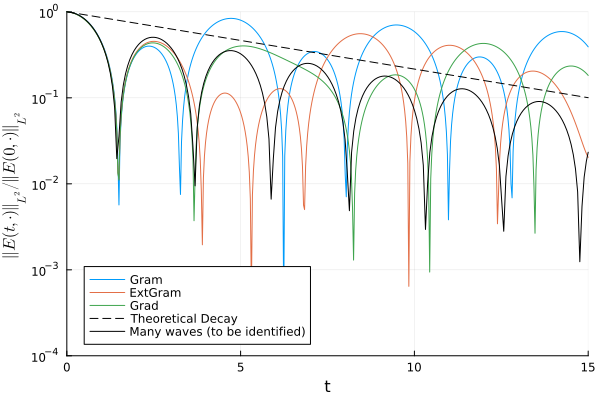

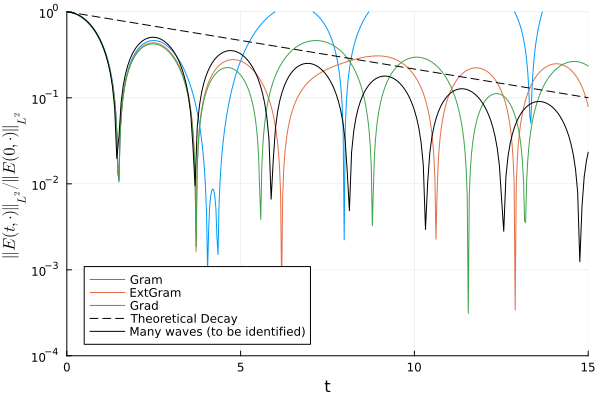

In [3]:
for M in M_vec
    p = plot()
    for closure in closures
        file = "../out/VlasovPoisson/energy_moments_closure$(closure)_T$(T_end)_M$(M)_k$(k)_ϵ$(ϵ)_p$(polydeg)_level$(base_tree_level).csv"
        data = CSV.read(file, DataFrame)
        plot!(
            p,
            data[!, :time], data[!, :E_L2_normalized],
            label="$closure",
            xlabel="t", 
            ylabel=L"∥E(t,⋅)∥_{L^2} / ∥E(0,⋅)∥_{L^2}",
            yaxis=:log
        )
        # plot theoretical decay only once
        if closure == closures[end]
            plot!(
                p,
                data[!, :time], data[!, :theoretical_decay],
                label="Theoretical Decay",
                linestyle=:dash,
                color=:black
            )
        end
    end
    # plot pnavaro reference data
    data = CSV.read("../out/VlasovPoisson/energy_pnavaro.csv", DataFrame)
    plot!(
        p,
        data[!, :time], data[!, :energy],
        label="Many waves (to be identified)",
        linestyle=:solid,
        color=:black
    )
    # legend to bottom left
    plot!(p, legend=:bottomleft)
    plot!(xlim=(0, T_end))
    plot!(ylim=(1e-4, 1.0))
    display(p)
    savefig(p, "../out/VlasovPoisson/energy_comparison_M$(M)_k$(k)_ϵ$(ϵ)_p$(polydeg)_level$(base_tree_level).pdf")
end